# Célula 1: Importação de Bibliotecas
Essa célula importa as bibliotecas necessárias para carregar dados, análise, modelagem e logging com MLflow.

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Para salvar o modelo

# Célula 2: Carregamento e Preparação dos Dados
Aqui, recriei o DataFrame a partir dos dados no Excel. Converti as datas seriais do Excel para datas reais (usando datetime), e limpei os dados.

In [47]:
# Dados extraídos do Excel fornecido
data_dict = {
    'data': [45809, 45810, 45811, 45812, 45813, 45814, 45815, 45816, 45817, 45818, 45819, 45820, 45821, 45822,
             45823, 45824, 45825, 45826, 45827, 45828, 45829, 45830, 45831, 45832, 45833, 45834, 45835, 45836,
             45837, 45838, 45839, 45840, 45841, 45842, 45843, 45844, 45845, 45846, 45847, 45848, 45849, 45850,
             45851, 45852, 45853, 45854, 45855, 45856, 45857, 45858, 45859, 45860, 45861, 45862, 45863, 45864,
             45865, 45866, 45867, 45868, 45869, 45870, 45871, 45872, 45873, 45874, 45875, 45876, 45877, 45878,
             45879, 45880, 45881, 45882, 45883, 45884, 45885, 45886, 45887, 45888, 45889, 45890, 45891, 45892,
             45893, 45894, 45895, 45896, 45897, 45898, 45899, 45900, 45901, 45902, 45903, 45904, 45905, 45906,
             45907, 45908, 45909, 45910, 45911, 45912, 45913, 45914, 45915, 45916, 45917, 45918, 45919, 45920,
             45921, 45922, 45923, 45924, 45925, 45926, 45927, 45928, 45929, 45930, 45931, 45932, 45933, 45934,
             45935, 45936, 45937, 45938, 45939, 45940, 45941, 45942, 45943, 45944],
    'vendas': [222.95, 45, 93.8, 130.9, 335.22, 60.2, 431.5, 436.31, 664.28, 491.85, 102.3, 0, 65.51, 95.5,
               361.8, 57, 82.5, 57, 132.21, 111.5, 387.71, 325.556, 98.35, 392.55, 68, 74.95, 42.05, 174.28,
               452.86, 16, 0, 359.31, 62.8, 258.47, 257.92, 410.65, 22, 181.92, 53, 152.12, 154.32, 208.45,
               550.58, 29, 137.54, 68.85, 108.75, 139.5, 441.03, 676.7, 42.75, 145.45, 607.54, 88, 72.55, 130.1,
               742.2, 126.76, 158.93, 339.69, 50.31, 0, 270.94, 420.11, 74.65, 76.6, 89.08, 123.77, 168.18, 1030.81,
               664.9, 29.8, 98.9, 54, 57, 54, 479.59, 283.59, 2, 151.66, 361.28, 76.36, 187.78, 368.47,
               705.54, 83.7, 94.7, 40.85, 99.85, 173.05, 515.81, 930.34, 63.25, 190.13, 111.5, 76.4, 182.42, 306.47,
               601.95, 131.95, 207.6, 118.41, 117.2, 139.42, 369.2, 786.95, 14, 51.65, 121.7, 139.87, 97, 472.59,
               803, 104.46, 80, 94.1, 118.55, 100.3, 211.75, 522.48, 159.9, 188.43, 90, 181.55, 321.88, 411.09,
               568.25, 107.7, 209.43, 215.8, 420.75, 222.6, 437.91, 747.25, 140.45, 76],
    'dia_semana': ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado',
                   'Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo', 'Segunda', 'Terça']
}

# Cria o DataFrame
df = pd.DataFrame(data_dict)

# Converte data serial do Excel para datetime (Excel conta dias desde 1900-01-01, com ajuste)
from datetime import datetime, timedelta
df['data'] = df['data'].apply(lambda x: datetime(1899, 12, 30) + timedelta(days=x))

# Remove zeros ou valores inválidos se necessário (ex: dias fechados)
df = df[df['vendas'] > 0]

# Salva como CSV para reprodutibilidade
df.to_csv('vendas_acai.csv', index=False)

print(df.head())
print(f"Forma do DataFrame: {df.shape}")

        data  vendas dia_semana
0 2025-06-01  222.95    Domingo
1 2025-06-02   45.00    Segunda
2 2025-06-03   93.80      Terça
3 2025-06-04  130.90     Quarta
4 2025-06-05  335.22     Quinta
Forma do DataFrame: (133, 3)


# Célula 3: Análise Exploratória de Dados (EDA)
Nessa etapa, explorei os dados com gráficos para entender padrões.

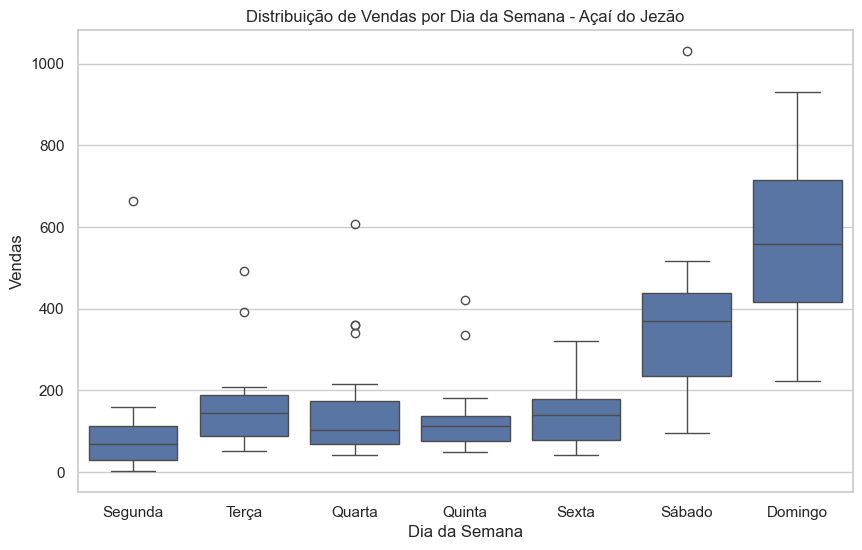

Médias de vendas por dia:
 dia_semana
Segunda    100.650000
Quinta     134.203333
Sexta      141.707222
Quarta     162.279474
Terça      163.665263
Sábado     368.480000
Domingo    560.698300
Name: vendas, dtype: float64


In [50]:
# Configura estilo dos gráficos
sns.set(style='whitegrid')

# Gráfico de vendas por dia da semana
plt.figure(figsize=(10, 6))
sns.boxplot(x='dia_semana', y='vendas', data=df, order=['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo'])
plt.title('Distribuição de Vendas por Dia da Semana - Açaí do Jezão')
plt.xlabel('Dia da Semana')
plt.ylabel('Vendas')
plt.savefig('vendas_por_dia.png')  # Salve para readme.md
plt.show()

# Médias
media_vendas = df.groupby('dia_semana')['vendas'].mean().sort_values()
print("Médias de vendas por dia:\n", media_vendas)

# Célula 4: Preparação dos Dados para Modelagem
Aqui, preparei as features (dia_semana como categórica) e dividir em treino/teste.

In [53]:
# Features e target
X = df[['dia_semana']]
y = df['vendas']

# Divide em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (106, 1), Teste: (27, 1)


# Célula 5: Criação e Treinamento do Pipeline com Modelo
Criei um pipeline com one-hot encoding e regressão linear.

In [56]:
# Pipeline: Encoding + Modelo
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), ['dia_semana'])]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())  # Ou RandomForestRegressor(n_estimators=100) para melhor performance
])

# Treina
model_pipeline.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


# Célula 6: Avaliação do Modelo
Avaliação com métricas como RMSE e R².

RMSE: 179.68 (erro médio de previsão)
R²: 0.41 (explicação da variância)


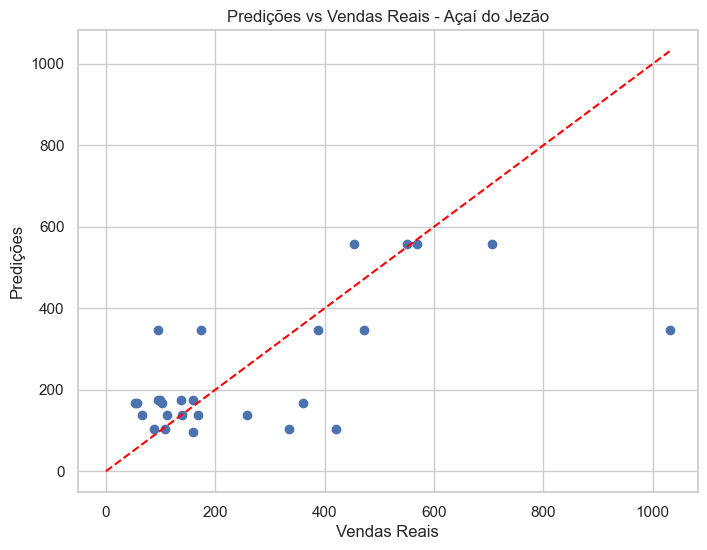

In [59]:
# Predições no teste
y_pred = model_pipeline.predict(X_test)

# Métricas (usando root_mean_squared_error para evitar o FutureWarning)
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} (erro médio de previsão)")
print(f"R²: {r2:.2f} (explicação da variância)")

# Gráfico de predições vs reais
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--')
plt.title('Predições vs Vendas Reais - Açaí do Jezão')
plt.xlabel('Vendas Reais')
plt.ylabel('Predições')
plt.savefig('predicoes_vs_reais.png')  # Salve para readme.md
plt.show()

# Célula 7: Registro do Modelo com MLflow
Usando MLflow para logar métricas, parâmetros e o modelo.

In [62]:
import warnings
warnings.filterwarnings("ignore")  # Ignora avisos de widgets

# Define o URI de rastreamento local
mlflow.set_tracking_uri("file:///./mlruns")

# Inicia um run no MLflow
with mlflow.start_run(run_name="Previsao_Vendas_Acai"):
    # Log parâmetros
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature", "dia_semana")
    
    # Log métricas
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Exemplo de entrada para inferir a assinatura
    input_example = pd.DataFrame({'dia_semana': ['Sábado']})
    
    # Log o modelo com 'name'
    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="modelo_acai",
        input_example=input_example
    )
    
    # Log artefatos
    mlflow.log_artifact('vendas_por_dia.png')
    mlflow.log_artifact('predicoes_vs_reais.png')

print("Modelo registrado no MLflow! Rode 'python -m mlflow ui' para visualizar.")

Modelo registrado no MLflow! Rode 'python -m mlflow ui' para visualizar.


# Célula 8: Salvar o Modelo e Fazer Previsões em Tempo Real
Salvei o modelo para uso futuro.

In [65]:
# Salva o modelo
joblib.dump(model_pipeline, 'modelo_acai.pkl')

# Exemplo de previsão
dia_exemplo = pd.DataFrame({'dia_semana': ['Sábado']})
previsao = model_pipeline.predict(dia_exemplo)
print(f"Previsão de vendas para Sábado: {previsao[0]:.2f}")

# Para uso real: Carregue com joblib.load('modelo_acai.pkl') e preveja.

Previsão de vendas para Sábado: 345.73
